## DNA viral diversity GLM multivariate

In [ ]:
##
##   Test which environmental/faunal variables independently drive viral DNA
##   diversity, using a MULTIVARIATE GLM (all predictors together). Each term's
##   significance is the F-test of the full model vs the model with that term
##   removed (drop1), i.e. the effect of each variable AFTER accounting for the
##   others. Each term is also shown as a PARTIAL-RESIDUAL plot, so the plotted
##   line equals that variable's multivariate coefficient.
##
## Response Indices: Shannon, Richness (all 119 genomes).
## Predictors: Core parsimonious set by default: Meiofauna, Macrofauna, O2_Cons, CH4_Flux
##
## Stats: Gaussian GLM; drop1 F-tests; VIF collinearity check; residual diagnostics.
##
## Outputs:
##   Table_diversity_multivariate.csv     : per index, each term's F, p, plus VIF
##   Table_diversity_multivariate_VIF.csv : VIF per predictor
##   Fig_partial_<index>__<variable>.pdf  : partial-residual plot per significant term
##   Fig_diagnostics_<index>.pdf          : residual diagnostics per index
## =============================================================================


In [4]:
# R libraries
library(vegan)
library(ggplot2)
library(dplyr)
library(car)

In [5]:
setwd("path/")

In [15]:
## CONFIG

VIRUS_FILE <- "data/DNA_Viruses119.txt"
MASTER     <- "data/Master_table_short.txt"
OUTDIR     <- "out_DNA-Virus_div_multivariate"
PRED       <- c("Meiofauna","O2_Cons","CH4_Flux")

LOG10_RESPONSE <- FALSE  # TRUE to log10-tragunsform diversity if residuals require
PLOT_ALL_TERMS <- FALSE  # FALSE = only significant terms get a partial plot; TRUE = all
SIG_CUT    <- 0.057
TRT_ORDER  <- c("Unmanip","HMM","HM","LM")
TRT_COL    <- c(Unmanip="#00970080", HMM="#ffce04ff", HM="#2a579bcb", LM="#cd534cff")

## ----------------------------------------------------------------------------
dir.create(OUTDIR, showWarnings = FALSE)


In [16]:
## viral diversity (response)

dv   <- read.table(VIRUS_FILE, header=TRUE, sep="\t", row.names=1, check.names=FALSE)
comm <- t(as.matrix(dv)); rel <- decostand(comm, "total")
div  <- data.frame(Sample=rownames(comm),
                   Shannon  = diversity(comm,"shannon"),
                   Richness = rowSums(rel>0))

In [17]:
## predictors

env <- read.table(MASTER, header=TRUE, sep="\t", check.names=FALSE,
                  na.strings=c("Na","NA",""), quote="", comment.char="")
colnames(env) <- c("Sample","Group","CH4_Conc","CH4_Flux","O2_Cons","Macrofauna",
                   "Meiofauna")
env$Group <- factor(env$Group, levels=TRT_ORDER)
dat <- merge(div, env, by="Sample")
dat <- dat[complete.cases(dat[,PRED]), ]

## z-score predictors so coefficients are comparable
datz <- dat; datz[PRED] <- lapply(dat[PRED], function(x) as.numeric(scale(x)))

metrics <- c("Shannon","Richness")

In [18]:
## fit multivariate GLM per index, drop1 F-tests

res <- list(); vif_tab <- list()
for (mt in metrics) {
  y <- if (LOG10_RESPONSE) log10(datz[[mt]]) else datz[[mt]]
  d1 <- data.frame(y = y, datz[, PRED, drop=FALSE])
  g  <- glm(y ~ ., data = d1)   # MULTIVARIATE: all predictors
  ft <- drop1(g, test = "F")
  r  <- data.frame(viral_index = mt, term = rownames(ft)[-1],
                   F = round(ft$`F value`[-1],3), p = round(ft$`Pr(>F)`[-1],4))
  res[[mt]] <- r

  ## VIF (same for every response since predictors identical; compute once)
  if (mt == metrics[1]) {
    v <- vif(g)
    vif_tab[["vif"]] <- data.frame(predictor = names(v), VIF = round(as.numeric(v),2))
  }

  ## residual diagnostics
  pdf(file.path(OUTDIR, paste0("Fig_diagnostics_", mt, ".pdf")), width=5, height=6)
  op <- par(mfrow=c(2,2)); plot(g); par(op); dev.off()
}
tab <- bind_rows(res)
write.csv(tab, file.path(OUTDIR,"Table_diversity_multivariate.csv"), row.names=FALSE)
write.csv(vif_tab[["vif"]], file.path(OUTDIR,"Table_diversity_multivariate_VIF.csv"), row.names=FALSE)

cat("=== MULTIVARIATE diversity GLM (drop1 F-tests; each term adjusted for the others) ===\n")
print(tab, row.names=FALSE)
cat("\nVIF (>5 would indicate collinearity):\n"); print(vif_tab[["vif"]], row.names=FALSE)

=== MULTIVARIATE diversity GLM (drop1 F-tests; each term adjusted for the others) ===
 viral_index      term     F      p
     Shannon Meiofauna 5.880 0.0244
     Shannon   O2_Cons 7.893 0.0105
     Shannon  CH4_Flux 7.661 0.0115
    Richness Meiofauna 6.889 0.0158
    Richness   O2_Cons 9.379 0.0059
    Richness  CH4_Flux 7.583 0.0119

VIF (>5 would indicate collinearity):
 predictor  VIF
 Meiofauna 1.04
   O2_Cons 1.62
  CH4_Flux 1.57


`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


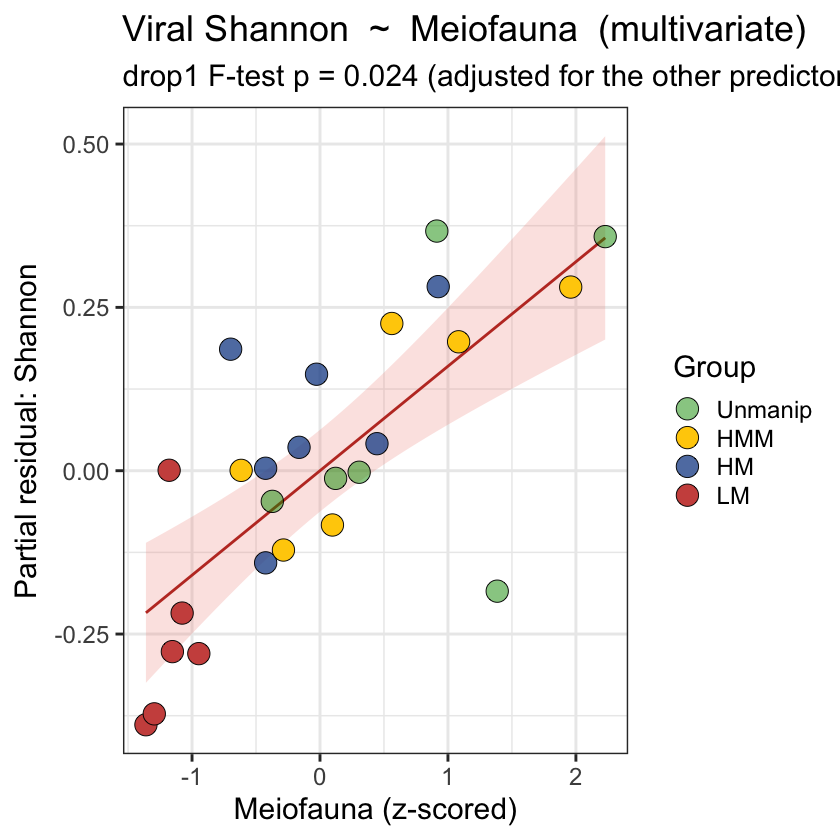

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


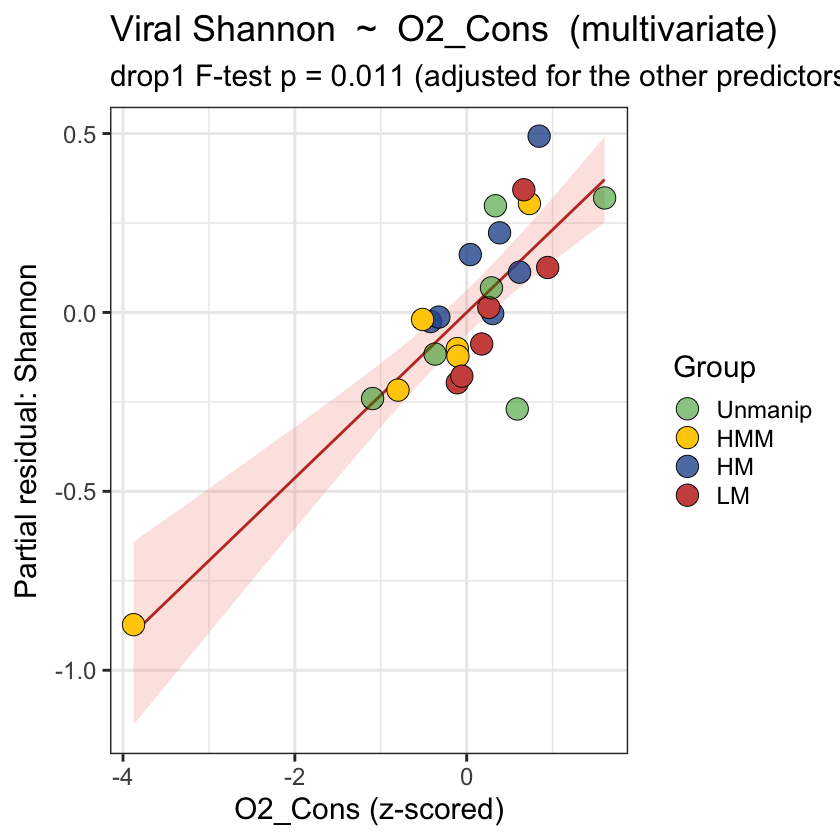

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


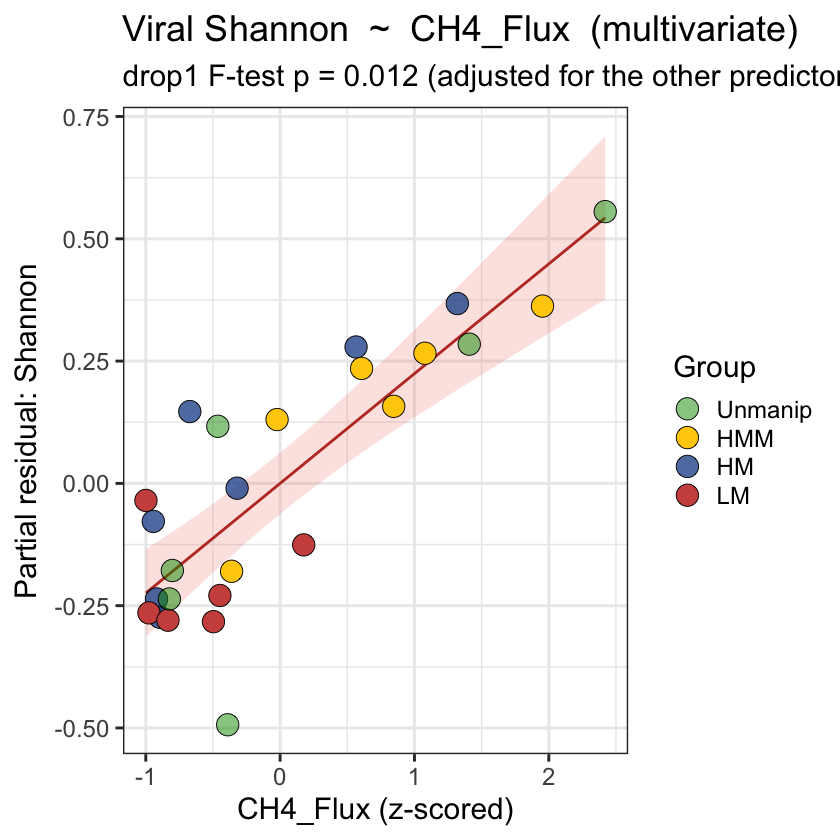

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


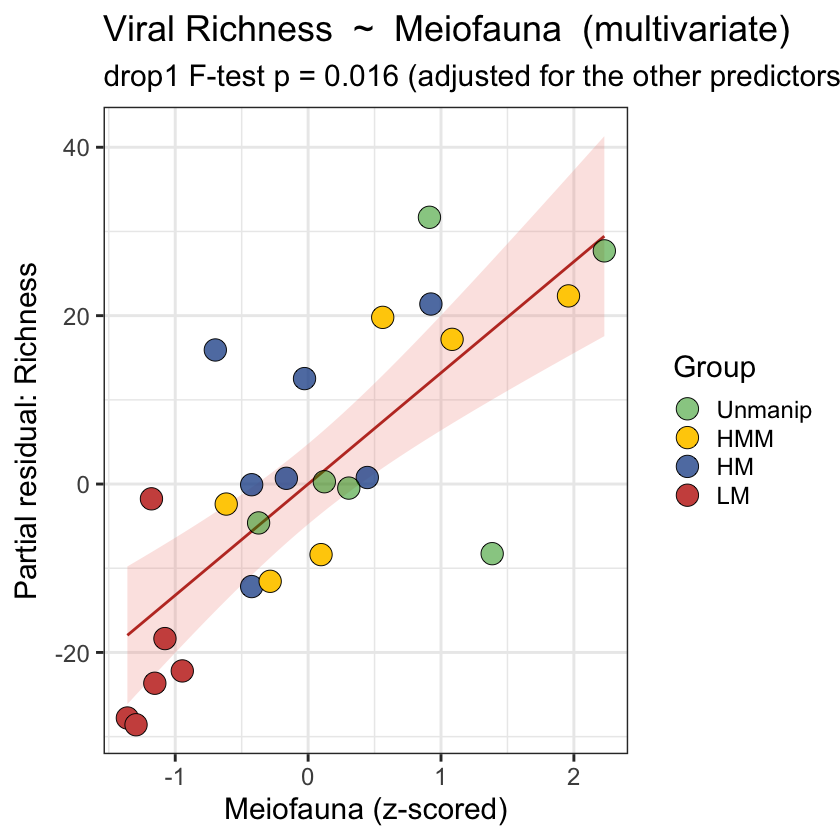

`geom_smooth()` using formula = 'y ~ x'


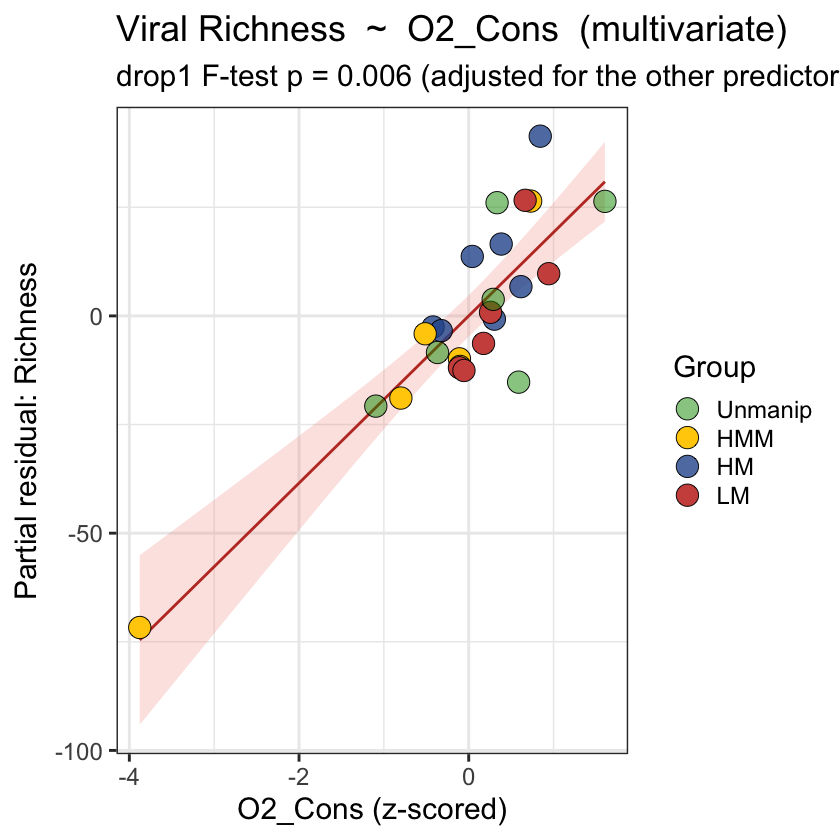


Significant terms (p < 0.057):
 viral_index      term     F      p
     Shannon Meiofauna 5.880 0.0244
     Shannon   O2_Cons 7.893 0.0105
     Shannon  CH4_Flux 7.661 0.0115
    Richness Meiofauna 6.889 0.0158
    Richness   O2_Cons 9.379 0.0059
    Richness  CH4_Flux 7.583 0.0119

Interpretation: a significant term means that variable predicts viral diversity
 AFTER accounting for the other predictors -> an independent effect. This is the

If residual diagnostics (Fig_diagnostics_*) show problems, set LOG10_RESPONSE<-TRUE.
Outputs -> out_DNA-Virus_div_multivariate/


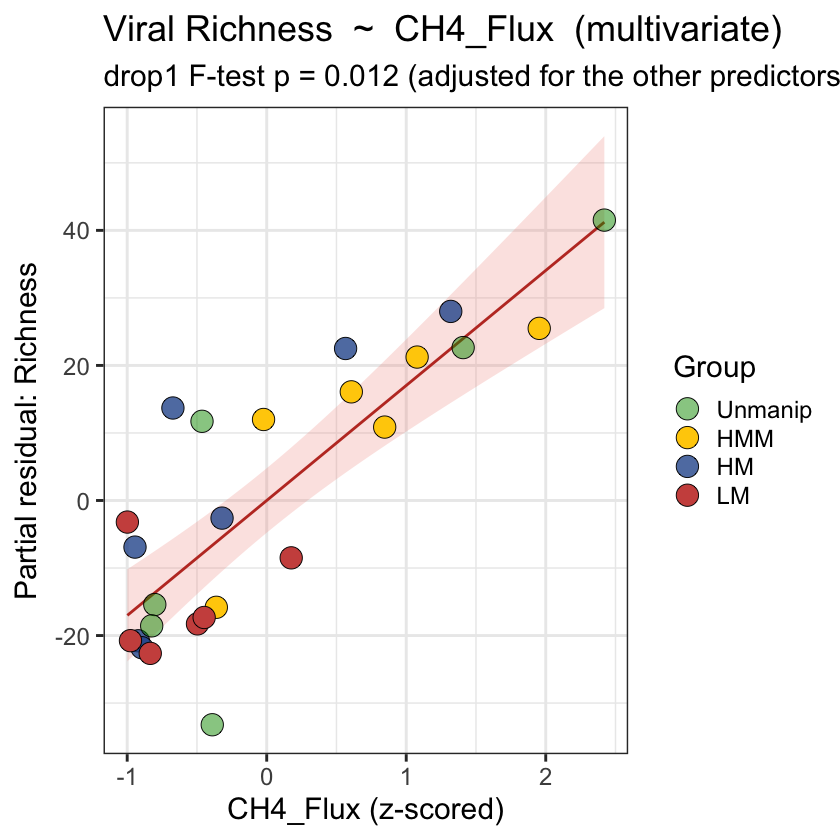

In [19]:
## partial-residual plots (line = multivariate coefficient)

for (mt in metrics) {
  y  <- if (LOG10_RESPONSE) log10(datz[[mt]]) else datz[[mt]]
  d1 <- data.frame(y=y, datz[,PRED,drop=FALSE]); g <- glm(y ~ ., data=d1)
  ft <- drop1(g, test="F"); pvals <- setNames(ft$`Pr(>F)`[-1], rownames(ft)[-1])
  terms_to_plot <- if (PLOT_ALL_TERMS) PRED else names(pvals)[which(pvals < SIG_CUT)]
  for (v in terms_to_plot) {
    pr  <- residuals(g, type="partial")[, v] + coef(g)[v]*d1[[v]]  # component + residual
    dfp <- data.frame(x = d1[[v]], pr = pr, Group = factor(dat$Group, levels=TRT_ORDER))
    pl <- ggplot(dfp, aes(x, pr)) +
      geom_smooth(method="lm", se=TRUE, colour="#C0392B", fill="#F1948A", alpha=.25, linewidth=.8) +
      geom_point(aes(fill=Group), shape=21, size=6, colour="black", stroke=.4) +
      scale_fill_manual(values=TRT_COL) +
      labs(x=paste0(v," (z-scored)"), y=paste("Partial residual:", mt),
           title=paste0("Viral ", mt, "  ~  ", v, "  (multivariate)"),
           subtitle=sprintf("drop1 F-test p = %.3f (adjusted for the other predictors)", pvals[v])) +
      theme_bw(base_size=18)
    ggsave(file.path(OUTDIR, paste0("Fig_partial_", mt, "__", v, ".pdf")), pl, width=4.5, height=5)

    print(pl)
  }
}

cat("\nSignificant terms (p < ", SIG_CUT, "):\n", sep="")
print(tab[tab$p < SIG_CUT, ], row.names=FALSE)
cat("\nInterpretation: a significant term means that variable predicts viral diversity\n",
    "AFTER accounting for the other predictors -> an independent effect. This is the\n")
cat("\nIf residual diagnostics (Fig_diagnostics_*) show problems, set LOG10_RESPONSE<-TRUE.\n")
cat("Outputs -> ", OUTDIR, "/\n", sep="")
